# <b>Email Spam Detection & Explainable AI Platform</b>

## Project Objective

The goal of this project is to build an intelligent email spam detection system using Natural Language Processing (NLP) and Machine Learning techniques.

The project aims to:

- Analyze spam and legitimate (ham) messages
- Understand key characteristics of spam messages
- Identify important words driving spam classification
- Prepare clean text data for machine learning models
- Build an explainable spam detection system

---

### Dataset Information

Dataset Shape:
- Rows: 5,572
- Columns: 3

Target Variable:
- 0 → Ham (Legitimate Message)
- 1 → Spam Message

After preprocessing:
- Text cleaned
- Stopwords removed
- Lemmatization applied
- Ready for NLP feature extraction

### <b>Step 1: Import the Libraries</b>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set_style("whitegrid")

### <b>Step 2: Load Dataset and Overview</b>

#### Dataset Overview

Before performing NLP analysis, we first understand:

- Dataset dimensions
- Missing values
- Data types
- Class distribution

In [2]:
df = pd.read_csv("../data/processed/spam_cleaned.csv")
df.head()
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print(df['Category'].value_counts())

Shape: (5572, 3)

Columns:
['Category', 'Message', 'CleanMessage']

Missing Values:
Category        0
Message         0
CleanMessage    6
dtype: int64

Data Types:
Category        int64
Message           str
CleanMessage      str
dtype: object
Category
0    4825
1     747
Name: count, dtype: int64


### <b>Step 3: Handle Missing Values in `CleanMessage`.

In [3]:
df[df['CleanMessage'].isna()][['Message']]

,Message
960,Where @
1612,645
2807,Can a not?
3376,:)
4575,:( but your not here....
4824,:-) :-)


In [4]:
print("Before:", df.shape)

df["CleanMessage"] = df["CleanMessage"].replace("", pd.NA)
df = df.dropna(subset=["CleanMessage"])

print("After:", df.shape)

Before: (5572, 3)
After: (5566, 3)


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Category        0
Message         0
CleanMessage    0
dtype: int64


#### Data Cleaning Summary

The dataset originally contained 5,572 messages.

During text preprocessing:
- Converted text to lowercase
- Removed URLs
- Removed punctuation
- Removed numbers
- Removed stopwords
- Applied lemmatization

After cleaning, 6 messages became empty because they contained only stopwords, symbols, or numeric values.

These records represented only 0.11% of the dataset and were removed.

Final dataset size:

- Original Records: 5,572
- Final Records: 5,566

Data quality remains excellent and suitable for NLP modeling.

### <b>Step 4: Class Distribution</b>

#### Spam vs Ham Distribution

This analysis helps us understand whether the dataset is balanced or imbalanced.

Class imbalance can significantly affect machine learning performance.

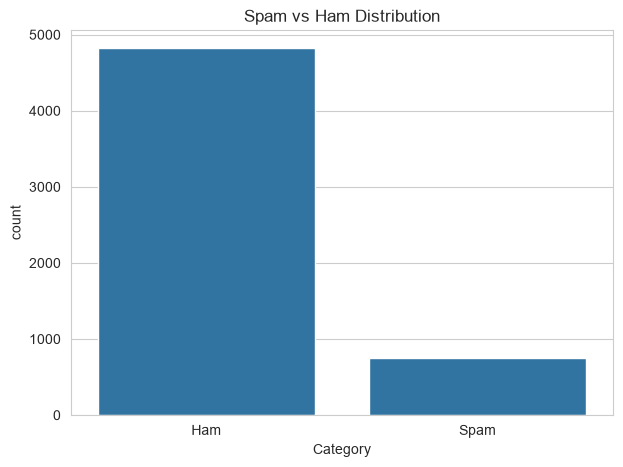

In [6]:
plt.figure(figsize=(7,5))
sns.countplot(x='Category', data=df)
plt.title("Spam vs Ham Distribution")
plt.xticks([0,1],["Ham", "Spam"])
plt.show()

#### Insights

- Ham messages significantly outnumber spam messages.
- Approximately 86% of messages are legitimate.
- Around 14% are spam.
- The dataset is moderately imbalanced and may require attention during model evaluation.

### <b> Step 5: Message Length Analysis</b>

#### Message Length Analysis

Spam messages often contain more content than legitimate messages.

We analyze the number of characters in each message.

In [7]:
df['MessageLength'] = df["Message"].apply(len)
df.groupby("Category")['MessageLength'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
0,4819.0,71.52625,58.428854,2.0,33.0,52.0,93.0,910.0
1,747.0,137.98929,29.980287,7.0,132.0,149.0,157.0,223.0


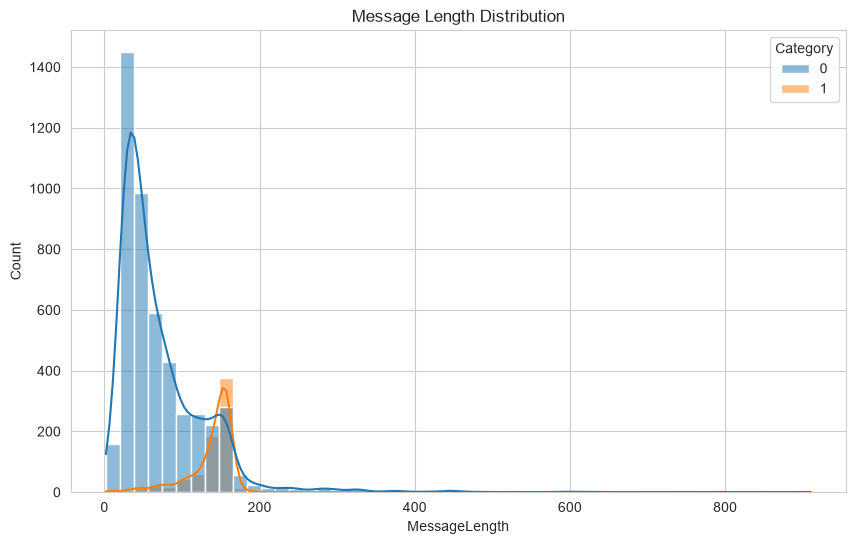

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="MessageLength",
    hue="Category",
    bins=50,
    kde=True
)
plt.title("Message Length Distribution")
plt.show()

#### Insights

- Spam messages tend to be longer than ham messages.
- Promotional content usually requires more words.
- Message length may become a useful predictive feature.

### <b>Step 6: Word Count Analysis</b>

#### Word Count Analysis

Word count helps us understand whether spam messages contain more textual content than legitimate messages.

In [9]:
df['WordCount'] = df['Message'].apply(lambda x: len(str(x).split()))
df.groupby('Category')['WordCount'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
0,4819.0,14.325171,11.517250,1.0,7.0,11.0,19.0,171.0
1,747.0,23.812584,5.956923,1.0,22.0,25.0,28.0,35.0


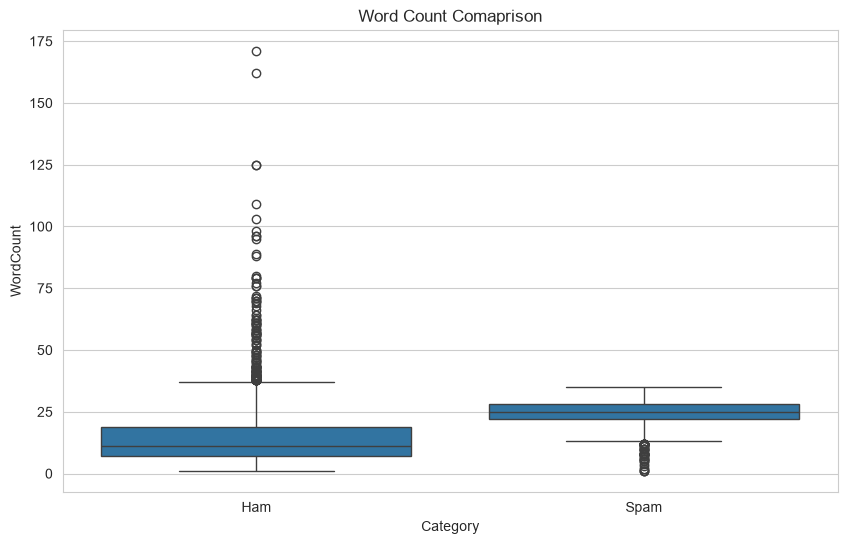

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Category', y='WordCount', data=df)
plt.xticks([0,1], ['Ham', 'Spam'])
plt.title("Word Count Comaprison")
plt.show()

#### Insights

- Spam messages generally contain more words.
- Spam exhibits greater variability in message size.
- Word count can serve as an additional engineered feature.

### <b>Step 7: Spam Word Cloud</b>

#### Most Frequent Words in Spam Messages

Word clouds help visualize frequently occurring words in spam communications.

In [11]:
spam_text = " ".join(df[df['Category']==1]['CleanMessage'])
Wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(spam_text)

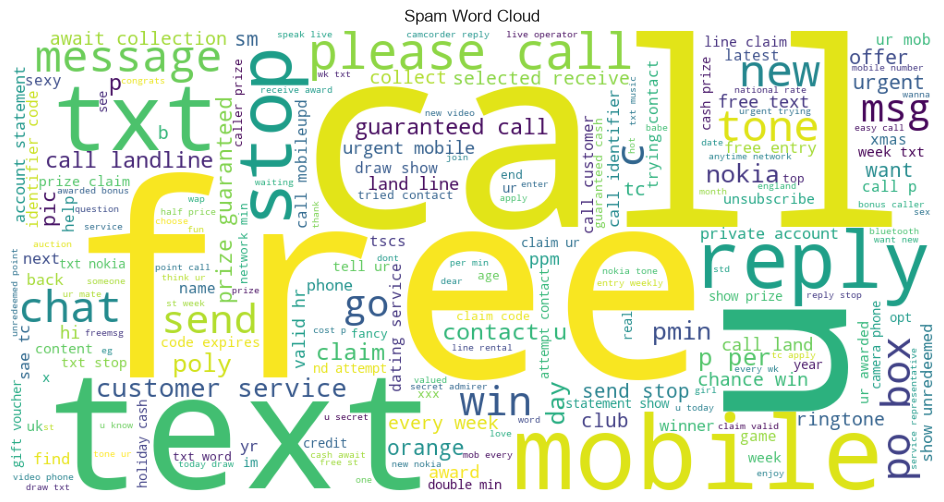

In [12]:
plt.figure(figsize=(15,6))
plt.imshow(Wordcloud)
plt.axis('off')
plt.title("Spam Word Cloud")
plt.show()

#### Insights

Common spam keywords include:
- free
- call
- win
- reply
- claim
- mobile
- txt

These words are strong indicators of promotional or fraudulent content.

### <b>Step 8: Ham Word Cloud</b>

#### Most Frequent Words in Legitimate Messages

Analyze common words appearing in non-spam messages.

In [13]:
ham_text = " ".join(df[df['Category']==0]['CleanMessage'])
ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(ham_text)

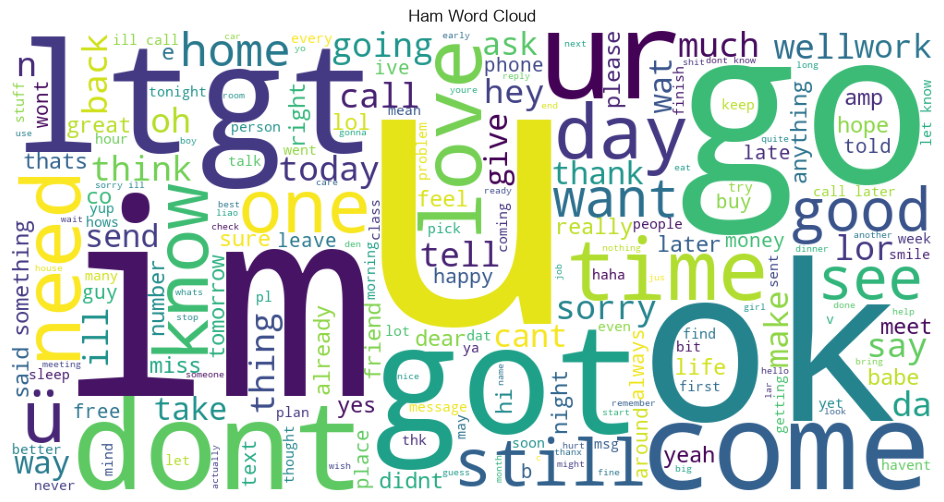

In [14]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wordcloud)
plt.axis('off')
plt.title("Ham Word Cloud")
plt.show()

#### Insights

Ham messages primarily contain:

- personal conversations
- scheduling discussions
- casual communication

The vocabulary differs significantly from spam messages.

### <b>Step 9: Top 20 Spam Keywords

#### Top Spam Keywords

Identify the most frequently occurring words in spam messages.

In [15]:
from collections import Counter
spam_words = []

for text in df[df['Category']==1]['CleanMessage']:
    spam_words.extend(text.split())

spam_freq = Counter(spam_words)

top_spam = pd.DataFrame(
    spam_freq.most_common(20), columns=['Word','Count']
)

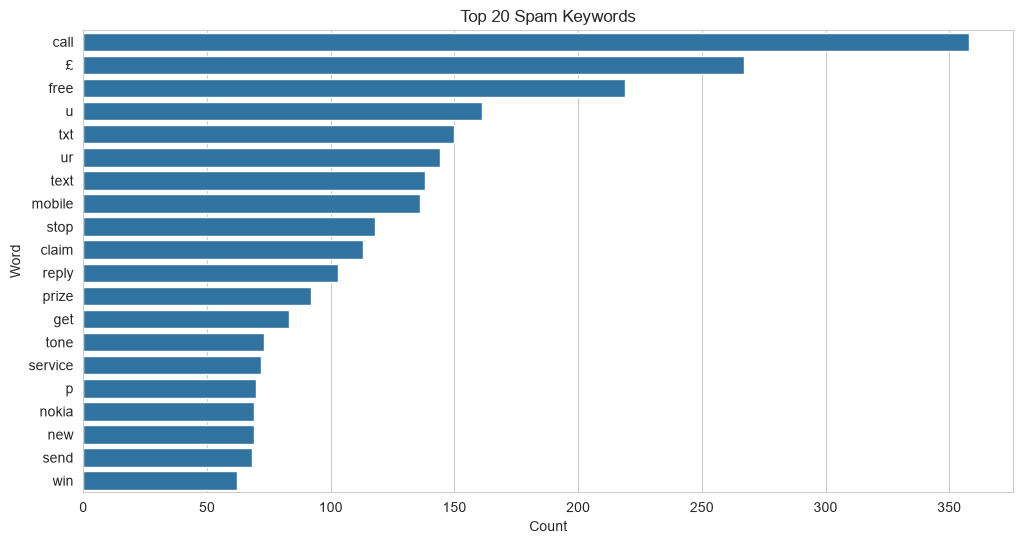

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_spam,
    x='Count',
    y='Word'
)
plt.title("Top 20 Spam Keywords")
plt.show()

#### Insights

The most influential spam words represent:

- financial incentives
- promotions
- rewards
- urgency

These patterns indicate strong linguistic signals that machine learning models can leverage.

### <b>CONCLUSION</b>

#### Summary

Key findings from the exploratory analysis:

#### Dataset Characteristics

- 5,572 messages analyzed
- Handle missing values
- Binary classification problem

#### Spam Behavior

- Spam messages are generally longer
- Spam contains more words
- Promotional language dominates spam content

#### NLP Findings

Strong spam indicators include:

- free
- win
- call
- reply
- claim

### <b>Next Steps</b>

- Convert text into numerical representations using TF-IDF
- Train multiple machine learning models
- Compare model performance
- Build Explainable AI dashboard
- Deploy spam detection platform